In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

# Add the src directory to the path. TEMPORARY FIX
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from src.data_processing.dataset_loader import CoastData

In [2]:
# Execute this cell to make sure 
# that external modules are reloaded
%load_ext autoreload
%autoreload 2

In [4]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../data/SCLabels_v1.0.0/"))

# Load the data, all the different stations
data = CoastData(data_path)

station_names = data.get_station_names()
print("Stations available: ", station_names)

CoastData: global - 1717 images
Stations available:  ['agrelo', 'arenaldentem', 'cadiz', 'cies', 'samarador']


In [39]:
k = 5
data_splits = data.get_kfold_splits(k, test_size=0.1)
print(data_splits.keys())

Coast: agrelo, Total size: 244
Coast: arenaldentem, Total size: 40
Coast: cadiz, Total size: 946
Coast: cies, Total size: 430
Coast: samarador, Total size: 57
dict_keys(['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4'])


In [40]:

for fold in data_splits.keys():
    total = (len(data_splits[fold]['train']['images']) +
             len(data_splits[fold]['validation']['images']) +
             len(data_splits[fold]['test']['images']))
    print(f"Total images in fold {fold}: {total}")
    print(f"Fold: {fold}")
    print("Fold train size: ", len(data_splits[fold]['train']['images']))
    print("Fold validation size: ", len(data_splits[fold]['validation']['images']))
    print("Fold test size: ", len(data_splits[fold]['test']['images']))
    print("")

Total images in fold fold_0: 1717
Fold: fold_0
Fold train size:  1237
Fold validation size:  307
Fold test size:  173

Total images in fold fold_1: 1717
Fold: fold_1
Fold train size:  1237
Fold validation size:  307
Fold test size:  173

Total images in fold fold_2: 1717
Fold: fold_2
Fold train size:  1237
Fold validation size:  307
Fold test size:  173

Total images in fold fold_3: 1717
Fold: fold_3
Fold train size:  1237
Fold validation size:  307
Fold test size:  173

Total images in fold fold_4: 1717
Fold: fold_4
Fold train size:  1228
Fold validation size:  316
Fold test size:  173



In [29]:
import pandas as pd
import os

file_roles = {}

for fold_name in data_splits.keys():
    for split_type in ['validation', 'train', 'test']:
        if data_splits[fold_name][split_type].get('images'):

            file_paths = data_splits[fold_name][split_type]['images']

            for file_path in file_paths:
                filename = os.path.basename(file_path)

                if filename not in file_roles:
                    file_roles[filename] = {}
                
                file_roles[filename][fold_name] = split_type

df = pd.DataFrame.from_dict(file_roles, orient='index')

df = df.reindex(columns=sorted(data_splits.keys()))
df = df.reset_index().rename(columns={'index': 'filename'})

output_filename = 'folds_summary.csv'
df.to_csv(output_filename, index=False)

print(df.head())

                                            filename      fold_0 fold_1  \
0  1555342200.Mon.Apr.15_16_30_00.CET.2019.agrelo...  validation  train   
1  1575910440.Mon.Dec.09_17_54_00.CET.2019.agrelo...  validation  train   
2  1549465320.Wed.Feb.06_16_02_00.CET.2019.agrelo...  validation  train   
3  1568737306.Tue.Sep.17_17_21_46.CET.2019.agrelo...  validation  train   
4  1572880800.Mon.Nov.04_16_20_00.CET.2019.agrelo...  validation  train   

  fold_2 fold_3 fold_4  
0  train  train  train  
1  train  train  train  
2  train  train  train  
3  train  train  train  
4  train  train  train  


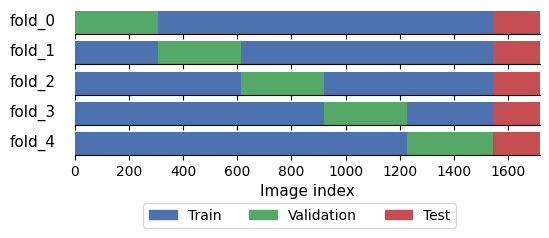

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import sys

# --- Load CSV ---
csv_path = 'folds_summary.csv'
try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"Error: El fitxer '{csv_path}' no s'ha trobat.")
    sys.exit()

# --- Settings ---
color_map = {'train': '#4C72B0', 'validation': '#55A868', 'test': '#C44E52'}
fold_cols = [col for col in df.columns if col.startswith('fold_')]
n_folds = len(fold_cols)

# --- Figure layout ---
fig = plt.figure(figsize=(6, n_folds * 0.5)) 
gs = gridspec.GridSpec(n_folds, 1, figure=fig,
                       height_ratios=[1]*n_folds, hspace=0.25)

axs_split = []

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

# --- Iterate folds ---
for i, fold in enumerate(fold_cols):
    ax_split = fig.add_subplot(gs[i, 0])
    axs_split.append(ax_split)

    # --- Plot: bar per image (visualize split) ---
    split_values = df[fold]
    colors = split_values.map(color_map)
    x_axis = range(len(split_values))
    y_axis = [1] * len(split_values)
    
    ax_split.bar(x_axis, y_axis, color=colors, width=1.0)
    ax_split.set_xlim([0, len(split_values)])
    ax_split.set_yticks([])
    ax_split.spines[['top', 'right', 'left']].set_visible(False)
    ax_split.set_ylabel(f'{fold}', rotation=0, labelpad=30, fontsize=11, va='center')

    # Hide x labels except for last
    if i < n_folds - 1:
        ax_split.tick_params(axis='x', labelbottom=False)
    else:
        ax_split.set_xlabel('Image index', fontsize=11)

# --- Add global legend ---
patches = [mpatches.Patch(color=color_map[c], label=c.capitalize())
           for c in color_map.keys()]
fig.legend(handles=patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02), prop={'size':10})

# plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.subplots_adjust(bottom=0.3)

output_filename = 'kfold_diagram.png'
plt.savefig(output_filename, bbox_inches='tight', dpi=300)